# Tree consistency: benchmark the row priors

**Question:** does learning `p(L_k | L_<k)` improve the tree factorization?

This notebook presents **60 completed fits** on the supplied notebook simulation
and a corrected tree: six configurations, five simulation seeds and thirty sweeps.
Every fit uses ordinary **ash column priors**. The notebook reads the saved run
records and figures by default; reproduction commands are at the end.
**Historical results:** the figures use neural penalty 1.05 and precede the
numerical corrections. New runs use CGB penalty 1.0511 and spiked EMDN penalty
1.1; those results are saved separately and have not replaced these figures.

The result is mixed: conditional CGB improves on plug-in CGB but remains worse
than ordinary generalized binary. Conditional spiked EMDN has the best mean error
of the three requested configurations, but ordinary spiked EMDN captures most of
that improvement and runs much faster. These results do not demonstrate a general
advantage of hierarchical learning.

See the [full audit and report](../output/tree_prior_benchmark/REPORT.md).

In [1]:
from pathlib import Path
import json
import sys
import statistics

import matplotlib.pyplot as plt
import torch

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src/cebmf_torch").is_dir())
RESULTS = ROOT / "output/tree_prior_benchmark"
SCRIPTS = ROOT / "examples/benchmarks/tree"
sys.path.insert(0, str(SCRIPTS))
from benchmark_tree_priors import simulate
from summarize_tree_benchmark import load_records, LABELS

torch.set_num_threads(1)
records = load_records(RESULTS / "main")
assert len(records) == 60 and all(r["complete"] for r in records)
print(f"Loaded {len(records)} completed fits; no models are being retrained.")

Loaded 60 completed fits; no models are being retrained.


## 1. Understand the simulation first

Each row has a root program, one branch and one leaf. The source notebook:

- uses the same `t11` sparsity mask for all four leaf feature factors;
- leaves zero-based rows **250, 500 and 750 without a leaf**;
- compares cold spiked EMDN with a warm start into a different CGB prior family;
- overwrites only `L` and `F` during that warm start, leaving their second moments
  inconsistent, and appends both warm and cold fits to the same plotting list.

The saved warnings refer to the former MCMC backend; the main fitting cell has no
execution count. Its historical RMSE values cannot be taken as verified outputs
of the currently displayed code. We leave that source notebook unchanged.

The corrected simulation uses separate leaf masks and covers every row. This is
not just cosmetic: its signal rank is **4**, versus **6** in the original.

In [2]:
for scenario in ("notebook", "corrected"):
    observed, signal, true_L, true_F = simulate(seed=1, scenario=scenario)
    missing_leaf = (true_L[:, 3:].sum(1) == 0).nonzero().flatten().tolist()
    print(f"{scenario:10s}: Y={tuple(observed.shape)}, "
          f"rank(L)={int(torch.linalg.matrix_rank(true_L.double()))}, "
          f"unique patterns={len(torch.unique(true_L, dim=0))}, "
          f"rows without leaf={missing_leaf}")

notebook  : Y=(1000, 200), rank(L)=6, unique patterns=6, rows without leaf=[250, 500, 750]
corrected : Y=(1000, 200), rank(L)=4, unique patterns=4, rows without leaf=[]


## 2. Compare matched fits

All main fits use the same SVD factors within a seed, `K=6`, estimated constant
noise, no pruning, and `prior_F="norm"` (ash, penalty 10). Neural fits use the
same compact settings: 12 hidden units, no additional hidden layer, two inner
epochs per sweep, batch size 128, learning rate 0.01 and spike penalty 1.05.
Spiked EMDN has one spike plus two Gaussian slabs. Conditional fits use 8-point
quadrature and 8 Sobol parent points. These are **benchmark settings**, not tuned
optima or the package defaults.

The three requested fits are:

```python
gb = cEBMF(Y, K=6, prior_L="gbinary", prior_F="norm", self_row_cov=False)
cgb_joint = cEBMF(Y, K=6, prior_L="cgb", prior_F="norm", self_row_cov=True)
mdn_joint = cEBMF(Y, K=6, prior_L="spiked_emdn", prior_F="norm", self_row_cov=True)
```

The benchmark also includes CGB without covariates, the old fixed-mean plug-in
CGB update, and spiked EMDN without covariates. That last control distinguishes
mixture flexibility from dependence between loadings. The driver explicitly sets
the common settings and initial factors omitted from the short snippet above.

**No covariates** means a constant input column, which becomes zero after
standardization. The network learns one shared prior per factor. CGB is a
zero spike plus one Gaussian slab; spiked EMDN here has two Gaussian slabs.
Posteriors still differ by row because observations differ. Plain CGB has
no `omega`; use `cgb_sharp` for that option. Its ordinary and joint variance
updates differ; see the [benchmark settings](benchmarks/tree/README.md).

**Score:** RMSE against the noiseless signal, using the last sweep. Smaller is
better. Simulation truth enters evaluation only. No held-out experiment or
hyperparameter search is implied by this table.

| Simulation | Row prior / update | Signal RMSE, mean +/- SD | Median seconds |
| --- | --- | ---: | ---: |
| notebook | GB (no covariates) | 0.1102 +/- 0.0113 | 120.8 |
| notebook | CGB (no covariates) | 0.1821 +/- 0.0061 | 11.8 |
| notebook | CGB plug-in | 0.1713 +/- 0.0036 | 12.6 |
| notebook | CGB joint VI | 0.1469 +/- 0.0030 | 153.2 |
| notebook | Spiked EMDN (no covariates) | 0.0900 +/- 0.0103 | 16.5 |
| notebook | Spiked EMDN joint VI | 0.0865 +/- 0.0061 | 366.8 |
| corrected | GB (no covariates) | 0.1153 +/- 0.0202 | 55.6 |
| corrected | CGB (no covariates) | 0.1811 +/- 0.0040 | 9.7 |
| corrected | CGB plug-in | 0.1724 +/- 0.0043 | 9.5 |
| corrected | CGB joint VI | 0.1462 +/- 0.0068 | 175.2 |
| corrected | Spiked EMDN (no covariates) | 0.0920 +/- 0.0031 | 15.8 |
| corrected | Spiked EMDN joint VI | 0.0869 +/- 0.0051 | 336.1 |


Times are per-fit wall times during concurrent single-thread CPU runs. They are
not an isolated hardware benchmark. Shared epoch counts do not imply identical
optimizer work or prior parameterization.

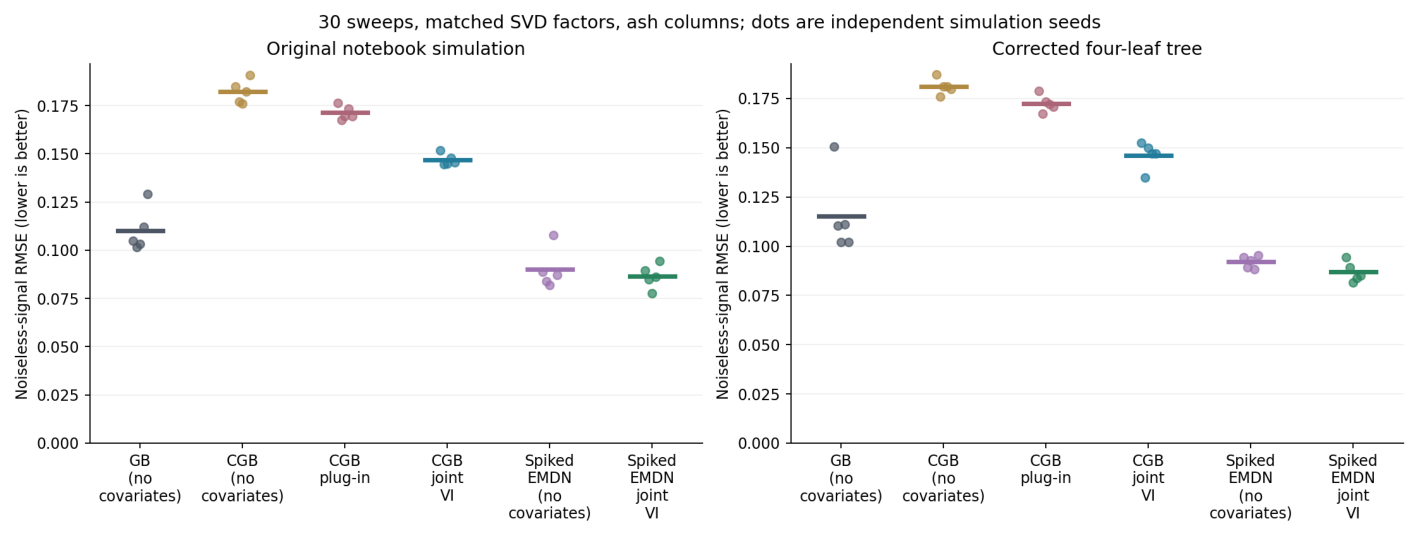

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(plt.imread(RESULTS / "rmse_comparison.png"))
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Accuracy versus computation

Conditional CGB improves on the plug-in control in all ten matched simulations.
For spiked EMDN, the extra gain from self covariates is modest: it wins against
the no-covariate version in **2/5** original and **4/5** corrected simulations.
Its median runtime is roughly **20 times greater** under this protocol.

The bands below are sample SDs across seeds, not confidence intervals. Initial
GB errors exceed the displayed vertical range in the first sweeps.

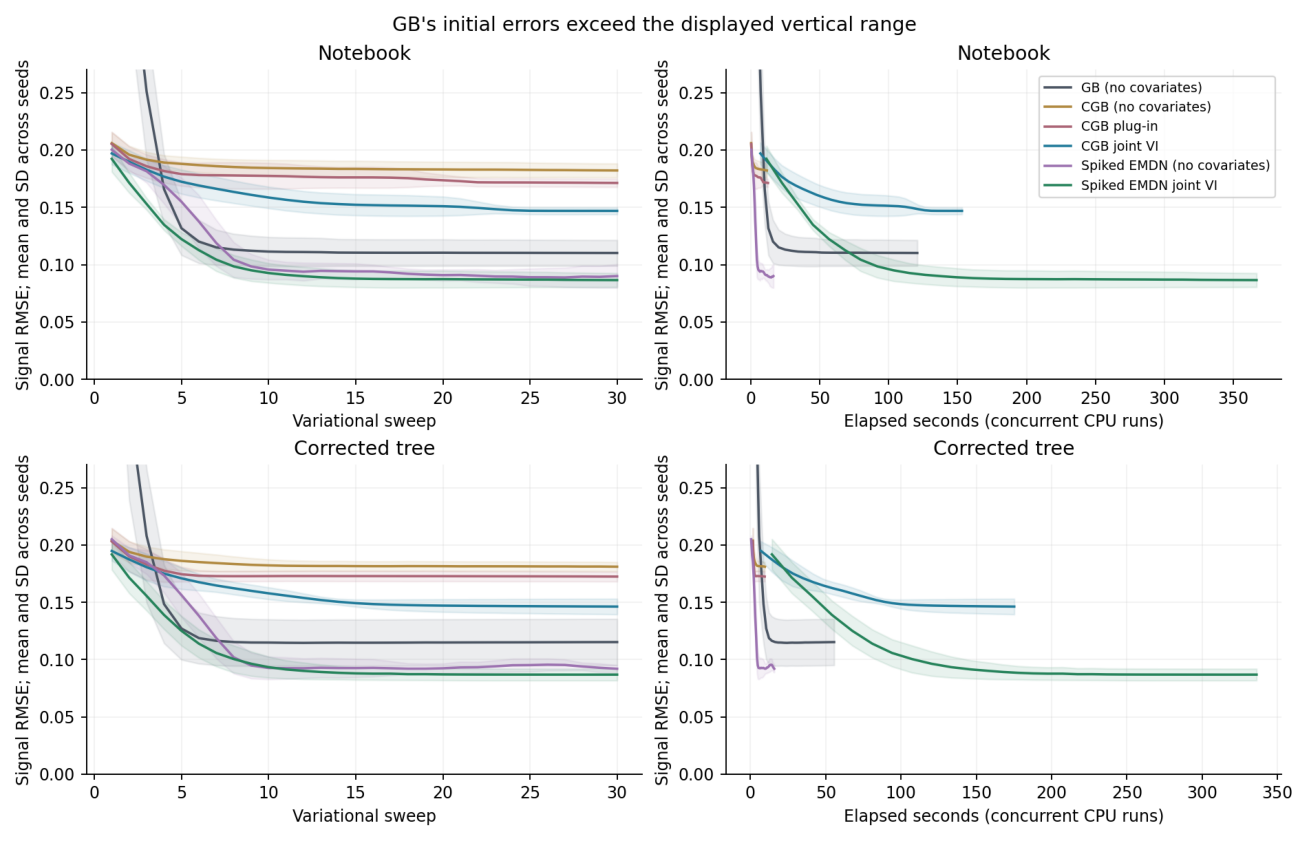

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(plt.imread(RESULTS / "learning_curves.png"))
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Initialization and prior shape matter

GB has a nonnegative truncated-normal slab; CGB has one unrestricted Gaussian
slab; spiked EMDN can represent multiple conditional means and scales. These are
different models. SVD can turn binary generating programs into signed contrasts.
In the fitted first seed, CGB covers the second contrast with a broad slab
(SD about 9), while spiked EMDN uses narrow positive and negative slabs.

The generating seven-column tree is redundant. In the corrected example,
`root = branch1 + branch2`, and each branch is a sum of two leaf indicators.
Recovering the exact named seven columns is therefore not an identifiable
requirement. Compare the signal, and interpret these heatmaps with that in mind.

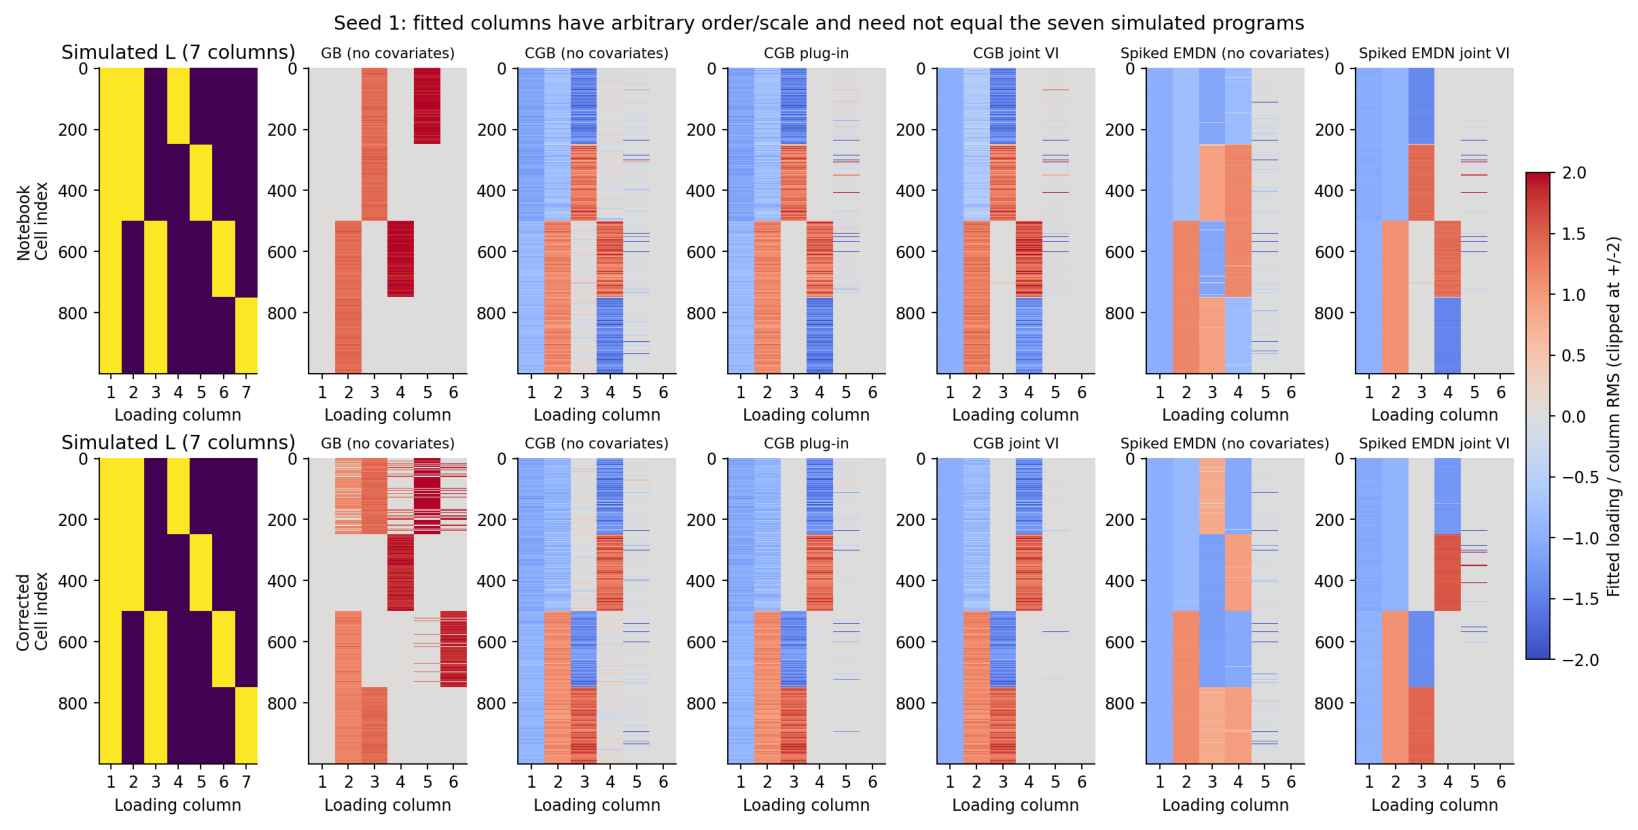

In [5]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.imshow(plt.imread(RESULTS / "loadings_seed1.png"))
ax.axis("off")
plt.tight_layout()
plt.show()

### Sensitivity checks

Raw SVD signs are particularly troublesome for GB: a mostly negative initial
loading can collapse to zero under its nonnegative prior. Flipping paired L/F
columns leaves their initial product unchanged. At `K=4`, this sign adjustment
reduces GB's mean RMSE from **0.2968 to 0.1124** over three corrected-tree seeds.
At `K=6`, mean GB performance is similar with and without this adjustment; see
the full report for both five-seed tables.

For original seed 1, a common ten-sweep GB warm start followed by twenty conditional
sweeps changes CGB RMSE from **0.1517 to 0.1075**, and spiked EMDN from **0.0893
to 0.0827**. By comparison, continuing the cold CGB fit for ten additional sweeps
with ten inner epochs barely changes its RMSE (**0.15173 to 0.15154**). These are
single-seed diagnostics, not a tuned or universally optimal initialization.

### Integration check

There is no MCMC chain in the current self-covariate fit. At the fitted first-seed
solutions, increasing local integration from 8/8 to 48/256 changes the combined
candidate signal by about **0.00026 RMS** for both models. This is small compared
with the CGB/spiked-EMDN gap. It is a local fixed-state check: it does not rerun
training trajectories or assess the factorized-posterior approximation.

In [6]:
for name in ("integration_cgb.json", "integration_spiked.json"):
    check = json.loads((RESULTS / name).read_text())[0]
    print(name, "rows:", len(check["evaluated_rows"]))
    for r in check["results"][:4]:
        print(f"  Q={r['quadrature']:2d}, parents={r['parents']:3d}: "
              f"candidate signal RMS difference={r['reconstruction_rms_change']:.7f}")

integration_cgb.json rows: 67
  Q= 8, parents=  8: candidate signal RMS difference=0.0002581
  Q=16, parents= 32: candidate signal RMS difference=0.0000588
  Q=32, parents=128: candidate signal RMS difference=0.0000119
  Q=48, parents=256: candidate signal RMS difference=0.0000000
integration_spiked.json rows: 67
  Q= 8, parents=  8: candidate signal RMS difference=0.0002584
  Q=16, parents= 32: candidate signal RMS difference=0.0000794
  Q=32, parents=128: candidate signal RMS difference=0.0000446
  Q=48, parents=256: candidate signal RMS difference=0.0000000


## 5. Run the comparison with the updated penalties

The following commands run from the repository root. Completed identical fits
are skipped. The full experiment can take many minutes; reading this notebook
does not launch it automatically. Do not run the same unfinished configuration
in two processes at once.
The driver now uses CGB penalty 1.0511 and spiked EMDN penalty 1.1, and
writes to `output/tree_prior_benchmark/penalty_20260916/main`. These commands
do not update the historical figures above. Add `--penalty 1.05` to use the
historical penalties with current code. For sharp CGB with omega 0.01, use
the optional `cgb_sharp`, `cgb_sharp_plugin`, and `cgb_sharp_self` methods.

```powershell
# One of the requested models on one simulation seed
python examples/benchmarks/tree/benchmark_tree_priors.py --seeds 1 --scenarios notebook --methods cgb_self --steps 30 --epochs 2 --hidden 12 --layers 0 --quadrature 8 --parents 8

# All 60 fits with the updated penalties
python examples/benchmarks/tree/benchmark_tree_priors.py --methods gbinary cgb cgb_plugin cgb_self spiked spiked_self --steps 30 --epochs 2 --hidden 12 --layers 0 --quadrature 8 --parents 8
# summarize_tree_benchmark.py still reads and plots the historical runs.
```

For the additional fits use the same shared settings and a separate output
directory, together with these options:

| Check | Additional options |
| --- | --- |
| Rank 4 | `--rank 4 --scenarios corrected --seeds 1 2 3 --methods gbinary cgb_self spiked_self --output output/tree_prior_benchmark/penalty_20260916/rank4` |
| GB sign sensitivity | `--orientation positive --methods gbinary --output output/tree_prior_benchmark/penalty_20260916/sign_orientation` |
| Rank 4 GB signs | `--rank 4 --orientation positive --scenarios corrected --seeds 1 2 3 --methods gbinary --output output/tree_prior_benchmark/penalty_20260916/rank4_oriented` |
| Common warm start | replace `--steps 30` with `--steps 20 --initialization gbwarm --warm-steps 10 --seeds 1 --scenarios notebook --methods cgb_self spiked_self --output output/tree_prior_benchmark/penalty_20260916/warm_start` |

`check_tree_integration.py CHECKPOINT.model.pt --output RESULT.json` reproduces
the integration diagnostic. `continue_tree_benchmark.py CHECKPOINT.model.pt
--steps 10 --epochs 10 --output RESULT.json` reproduces the extra-training check.
Use checkpoints created by this benchmark locally.

**Interpretation:** this is evidence about these finite-budget Gaussian tree
simulations. It supports investigating prior shape, initialization and computation
before attributing weaker CGB performance to sampling or an incorrect joint model.